In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Title

### Setting up and cleaning initial pandas dataframes

In [2]:
# Load the csv into a pandas database
netflix = pd.read_csv('netflix_titles.csv', keep_default_na=False)
netflix.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Remove director, cast, dated_added, and description columns 
# since we aren't going to be using them in our project.
netflix_cleaned = netflix.drop(columns=['director', 'cast', 'date_added', 'description'])
netflix_cleaned = netflix_cleaned[netflix_cleaned['country'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != '']
#netflix_cleaned = netflix_cleaned[netflix_cleaned['rating'] != 'NR']
netflix_cleaned.head(5)

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"


In [4]:
# Sub-database holding just movies
netflix_movies = netflix_cleaned[netflix_cleaned['type'] == 'Movie']
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,TV-MA,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [5]:
# Sub-database holding just tv shows
netflix_shows = netflix_cleaned[netflix_cleaned['type'] == 'TV Show']
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,TV-Y7,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,TV-Y7,3 Seasons,Kids' TV


### Sorting Data by Ratings for Visualization

In [6]:
ratings_movie = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR'
}

netflix_movies = netflix_movies.copy()
netflix_movies.loc[:, 'rating'] = (
    netflix_movies['rating']
    .str.strip()
    .str.upper()
    .map(ratings_movie)
    .fillna('UR')
)

netflix_movies_filtered = netflix_movies.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_movies_filtered

,release_year,rating,count
0,1942,PG-13,2
1,1943,PG,3
2,1944,PG,1
3,1944,PG-13,2
4,1945,PG-13,2
...,...,...,...
232,2020,R,250
233,2021,G,12
234,2021,PG,21
235,2021,PG-13,53


In [7]:
ratings_show = {
    # G
    'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'TV-Y7-FV': 'G',

    # PG
    'PG': 'PG', 'TV-PG': 'PG',

    # PG-13
    'PG-13': 'PG-13', 'TV-14': 'PG-13',

    # R
    'R': 'R', 'NC-17': 'R', 'TV-MA': 'R',

    # UR
    'UR': 'UR', 'NR': 'UR'
}

netflix_shows = netflix_shows.copy()
netflix_shows.loc[:, 'rating'] = (
    netflix_shows['rating']
    .fillna('UR')
    .astype(str)
    .str.strip()
    .str.upper()
    .map(ratings_show)
    .fillna('UR')
)

netflix_shows_filtered = netflix_shows.groupby(['release_year', 'rating']).size().reset_index(name='count')
netflix_shows_filtered

,release_year,rating,count
0,1945,R,1
1,1946,PG-13,1
2,1963,PG-13,1
3,1967,G,1
4,1972,R,1
...,...,...,...
113,2020,R,233
114,2021,G,38
115,2021,PG,13
116,2021,PG-13,55


### Graphing Data

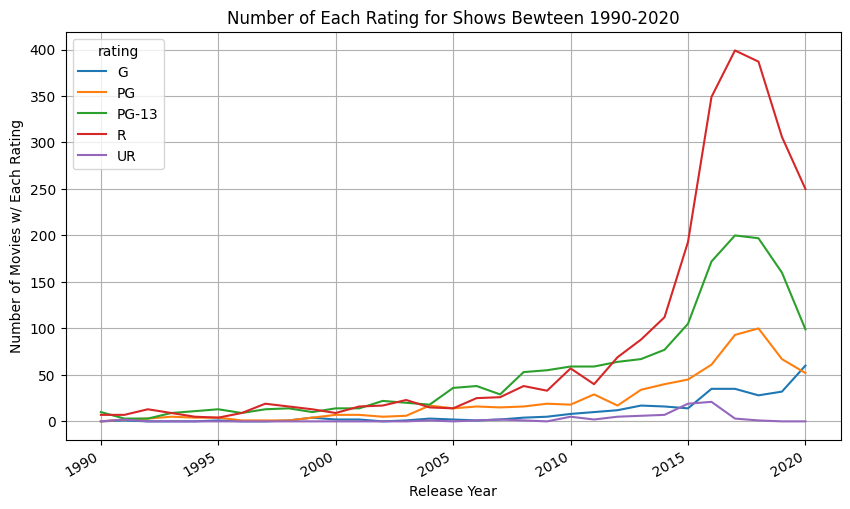

In [8]:
netflix_movies_agg = netflix_movies_filtered.groupby(['release_year', 'rating'])['count'].sum().reset_index()
pivoted_counts = netflix_movies_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

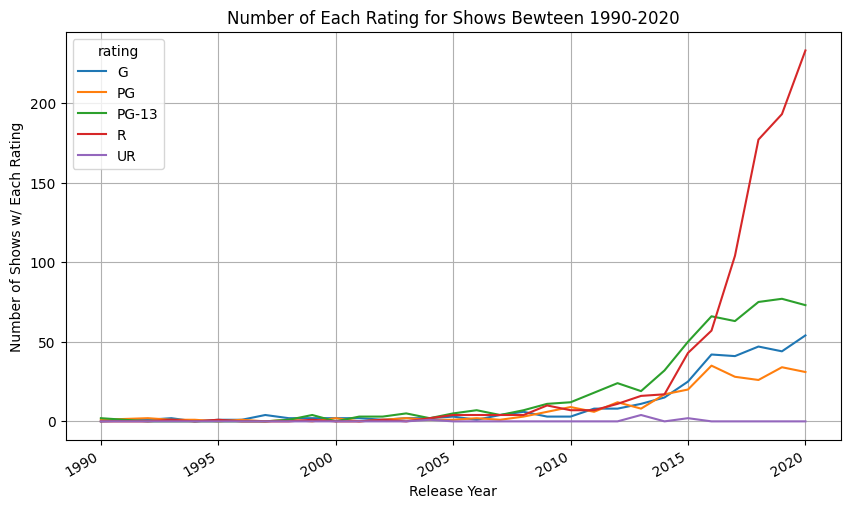

In [9]:
netflix_shows_agg = netflix_shows_filtered.groupby(['release_year', 'rating']).sum().reset_index()
pivoted_counts = netflix_shows_agg.pivot(index='release_year', columns='rating', values='count').fillna(0)
pivoted_counts = pivoted_counts.sort_index().loc[1990:2020]
pivoted_counts.plot(kind='line', figsize=(10, 6))

plt.title("Number of Each Rating for Shows Bewteen 1990-2020")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows w/ Each Rating")

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

### Splitting up the 'listed_in' column for visualitation and future models

In [10]:
count = (
    netflix_movies['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
count

listed_in
International Movies        2543
Dramas                      2317
Comedies                    1580
Action & Adventure           817
Documentaries                794
Independent Movies           745
Romantic Movies              588
Thrillers                    549
Children & Family Movies     535
Horror Movies                340
Music & Musicals             328
Stand-Up Comedy              311
Sci-Fi & Fantasy             242
Sports Movies                201
Classic Movies               115
LGBTQ Movies                  97
Cult Movies                   70
Faith & Spirituality          63
Anime Features                63
Movies                        34
Name: count, dtype: int64

In [11]:
count = (
    netflix_shows['listed_in']
    .str.split(',')   # turn "apple,banana" → ['apple','banana']
    .explode()        # flatten
    .str.strip()      # remove spaces like " banana"
    .value_counts()   # count
)
count

listed_in
International TV Shows          1128
TV Dramas                        663
TV Comedies                      501
Crime TV Shows                   421
Kids' TV                         370
Docuseries                       330
Romantic TV Shows                299
British TV Shows                 237
Reality TV                       205
Anime Series                     154
TV Action & Adventure            153
Spanish-Language TV Shows        145
Korean TV Shows                  136
TV Mysteries                      92
Science & Nature TV               82
TV Sci-Fi & Fantasy               79
TV Horror                         72
Teen TV Shows                     66
TV Thrillers                      53
Stand-Up Comedy & Talk Shows      47
Classic & Cult TV                 27
TV Shows                           9
Name: count, dtype: int64

### Logistic Regression


Question: Does the duraton of a movie/show influence its rating?
- Using "duration" to predict "rating"
- Duration for movies is in number of minutes
- Duration for shows is in number of seasons

In [12]:
""" Setting up movie data """
# List of most common movie ratings
possible_movie_ratings = ['G', 'PG', 'PG-13', 'R']

# Copies the rating and duration columns from the original netflix movie df
movie_rating_duration = netflix_movies[['rating', 'duration']].copy()

# Removes any ratings that don't match the list above.
# We need to since there are some movies with the 'UR' rating (un-rated), as well as just invalid entries
movie_rating_duration = movie_rating_duration[movie_rating_duration["rating"].isin(possible_movie_ratings)].reset_index(drop=True)

# Turns the duration into an integer of minutes instead of it being a string with ' min' at the end
movie_rating_duration["duration"] = movie_rating_duration["duration"].str[:-4].astype(int)

movie_rating_duration

,rating,duration
0,PG-13,90
1,R,125
2,PG-13,104
3,R,127
4,PG-13,166
...,...,...
5604,R,96
5605,R,158
5606,R,88
5607,PG,88


In [13]:
""" Setting up show data """
# List of most common show ratings
possible_show_ratings = ['G', 'PG', 'PG-13', 'R']

# Copies the rating and duration columns from the original netflix movie df
show_rating_duration = netflix_shows[['rating', 'duration']].copy()

# Removes any ratings that don't match the list above
show_rating_duration = show_rating_duration[show_rating_duration["rating"].isin(possible_show_ratings)].reset_index(drop=True)

# Turns the duration into an integer of seasons instead of it being a string with 'Seasons' at the end
show_rating_duration["duration"] = show_rating_duration["duration"].str[:-7].astype(int)

show_rating_duration

,rating,duration
0,R,2
1,R,2
2,PG-13,9
3,R,4
4,R,2
...,...,...
2273,G,1
2274,G,2
2275,PG,2
2276,G,3


In [14]:
""" Getting the X and Y values for movies and shows to be used in logistic regression """
# Movie
X_movie = movie_rating_duration[["duration"]]
Y_movie = movie_rating_duration['rating']

# Show
X_show = show_rating_duration[['duration']]
Y_show = show_rating_duration['rating']

In [15]:
""" Make the models """
# Create logistic regression models
movie_model = LogisticRegression()
show_model = LogisticRegression()

movie_model.fit(X_movie, Y_movie)
show_model.fit(X_show, Y_show)



LogisticRegression()

In [16]:
""" Running probability models to get predictions """
movie_prob = movie_model.predict_proba(X_movie)
show_prob = show_model.predict_proba(X_show)


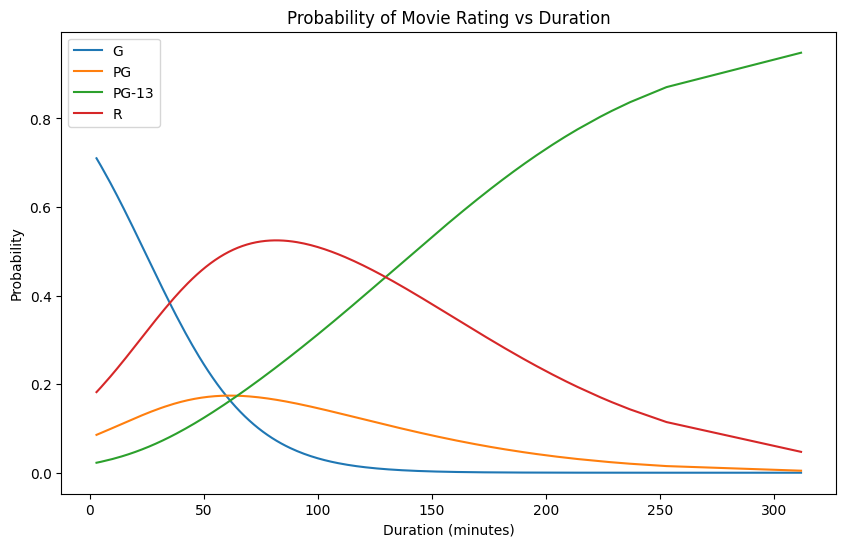

In [17]:
""" Display Movie Results """
movie_prob_df = pd.DataFrame(movie_prob, columns=possible_movie_ratings)
movie_prob_df["duration"] = X_movie["duration"].to_numpy()
movie_plot = movie_prob_df.sort_values("duration")

# movie_prob_df

plt.figure(figsize=(10,6))
for r in possible_movie_ratings:
    plt.plot(movie_plot["duration"], movie_plot[r], label=r)

plt.xlabel("Duration (minutes)")
plt.ylabel("Probability")
plt.title("Probability of Movie Rating vs Duration")
plt.legend()
plt.show()


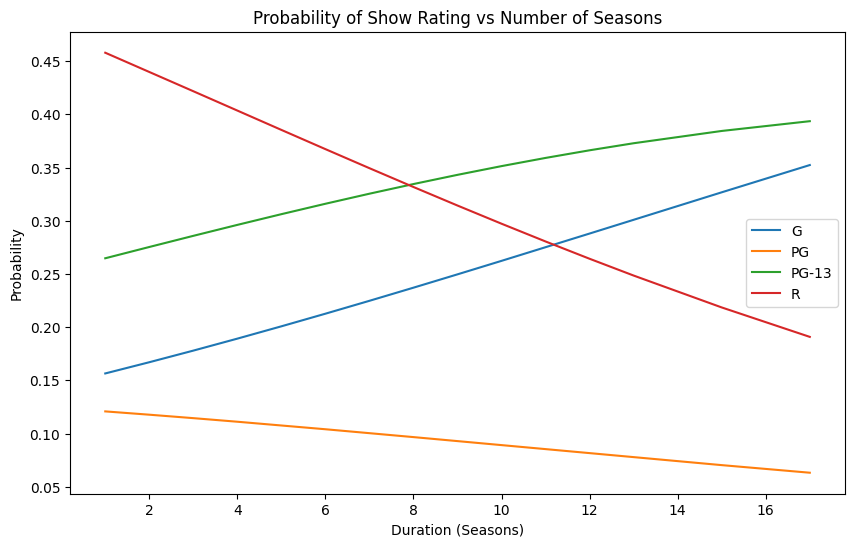

In [18]:
""" Display Show Results """
show_prob_df = pd.DataFrame(show_prob, columns=possible_show_ratings)
show_prob_df["duration"] = X_show["duration"].to_numpy()
show_plot = show_prob_df.sort_values("duration")

# show_prob_df

plt.figure(figsize=(10,6))
for r in possible_show_ratings:
    plt.plot(show_plot["duration"], show_plot[r], label=r)

plt.xlabel("Duration (Seasons)")
plt.ylabel("Probability")
plt.title("Probability of Show Rating vs Number of Seasons")
plt.legend()
plt.show()

### Random Forest

Question: Is their a correlation between the rating of a movie and both its title and genre?
- Looking for rating using the "title" and "listed_in" columns of both movies and shows

In [19]:
netflix_shows

,show_id,type,title,country,release_year,rating,duration,listed_in
1,s2,TV Show,Blood & Water,South Africa,2021,R,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,s5,TV Show,Kota Factory,India,2021,R,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
8,s9,TV Show,The Great British Baking Show,United Kingdom,2021,PG-13,9 Seasons,"British TV Shows, Reality TV"
15,s16,TV Show,Dear White People,United States,2021,R,4 Seasons,"TV Comedies, TV Dramas"
17,s18,TV Show,Falsa identidad,Mexico,2020,R,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...,...,...,...,...,...
8780,s8781,TV Show,Yo-Kai Watch,United States,2015,G,1 Season,"Anime Series, Kids' TV"
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,"Japan, Canada",2015,G,2 Seasons,"Anime Series, Kids' TV"
8796,s8797,TV Show,Yunus Emre,Turkey,2016,PG,2 Seasons,"International TV Shows, TV Dramas"
8797,s8798,TV Show,Zak Storm,"United States, France, South Korea, Indonesia",2016,G,3 Seasons,Kids' TV


In [20]:
netflix_movies

,show_id,type,title,country,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...",1993,R,125 min,"Dramas, Independent Movies, International Movies"
9,s10,Movie,The Starling,United States,2021,PG-13,104 min,"Comedies, Dramas"
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic",2021,R,127 min,"Dramas, International Movies"
24,s25,Movie,Jeans,India,1998,PG-13,166 min,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,"United Arab Emirates, Jordan",2015,R,96 min,"Dramas, International Movies, Thrillers"
8802,s8803,Movie,Zodiac,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,s8805,Movie,Zombieland,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


### Preparing the Data
I will start by dropping irrelevant columns

In [21]:
movies_forest = netflix_movies[["title", "rating", "listed_in"]]
shows_forest = netflix_shows[["title", "rating", "listed_in"]]

In [22]:
movies_forest

,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,Documentaries
7,Sankofa,R,"Dramas, Independent Movies, International Movies"
9,The Starling,PG-13,"Comedies, Dramas"
12,Je Suis Karl,R,"Dramas, International Movies"
24,Jeans,PG-13,"Comedies, International Movies, Romantic Movies"
...,...,...,...
8801,Zinzana,R,"Dramas, International Movies, Thrillers"
8802,Zodiac,R,"Cult Movies, Dramas, Thrillers"
8804,Zombieland,R,"Comedies, Horror Movies"
8805,Zoom,PG,"Children & Family Movies, Comedies"


### Multi-Hot Encoding
Because out listed_in column is including multiple items in the column, we must manipulate the data so that our model can read it. We do this by performing multi-hot encoding, which will give each possible "listed_in" category a column, and a binary input describing if it is included in that show/movie or not

We will do this by using scikit-learn's MultiLabelBinarizer

Starting with movies dataframe

In [23]:
movies_forest

,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,Documentaries
7,Sankofa,R,"Dramas, Independent Movies, International Movies"
9,The Starling,PG-13,"Comedies, Dramas"
12,Je Suis Karl,R,"Dramas, International Movies"
24,Jeans,PG-13,"Comedies, International Movies, Romantic Movies"
...,...,...,...
8801,Zinzana,R,"Dramas, International Movies, Thrillers"
8802,Zodiac,R,"Cult Movies, Dramas, Thrillers"
8804,Zombieland,R,"Comedies, Horror Movies"
8805,Zoom,PG,"Children & Family Movies, Comedies"


In [24]:
movies_forest["listed_in"] = movies_forest["listed_in"].str.split(", ")
movies_forest

/var/folders/rt/97q0d15d7yxf2bsktm0lwqyh0000gn/T/ipykernel_93256/1675168003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_forest["listed_in"] = movies_forest["listed_in"].str.split(", ")


,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,[Documentaries]
7,Sankofa,R,"[Dramas, Independent Movies, International Mov..."
9,The Starling,PG-13,"[Comedies, Dramas]"
12,Je Suis Karl,R,"[Dramas, International Movies]"
24,Jeans,PG-13,"[Comedies, International Movies, Romantic Movies]"
...,...,...,...
8801,Zinzana,R,"[Dramas, International Movies, Thrillers]"
8802,Zodiac,R,"[Cult Movies, Dramas, Thrillers]"
8804,Zombieland,R,"[Comedies, Horror Movies]"
8805,Zoom,PG,"[Children & Family Movies, Comedies]"


In [25]:
movies_forest["listed_in"] = movies_forest["listed_in"].fillna("")
movies_forest

/var/folders/rt/97q0d15d7yxf2bsktm0lwqyh0000gn/T/ipykernel_93256/2451414714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_forest["listed_in"] = movies_forest["listed_in"].fillna("")


,title,rating,listed_in
0,Dick Johnson Is Dead,PG-13,[Documentaries]
7,Sankofa,R,"[Dramas, Independent Movies, International Mov..."
9,The Starling,PG-13,"[Comedies, Dramas]"
12,Je Suis Karl,R,"[Dramas, International Movies]"
24,Jeans,PG-13,"[Comedies, International Movies, Romantic Movies]"
...,...,...,...
8801,Zinzana,R,"[Dramas, International Movies, Thrillers]"
8802,Zodiac,R,"[Cult Movies, Dramas, Thrillers]"
8804,Zombieland,R,"[Comedies, Horror Movies]"
8805,Zoom,PG,"[Children & Family Movies, Comedies]"


In [26]:
# Call the binarizer
mlb = MultiLabelBinarizer()
# Movie Dataframe
transform_movies = mlb.fit_transform(movies_forest["listed_in"])
mlb.classes_

array(['Action & Adventure', 'Anime Features', 'Children & Family Movies',
       'Classic Movies', 'Comedies', 'Cult Movies', 'Documentaries',
       'Dramas', 'Faith & Spirituality', 'Horror Movies',
       'Independent Movies', 'International Movies', 'LGBTQ Movies',
       'Movies', 'Music & Musicals', 'Romantic Movies',
       'Sci-Fi & Fantasy', 'Sports Movies', 'Stand-Up Comedy',
       'Thrillers'], dtype=object)

In [27]:
reset_movies_listed_in = pd.DataFrame(transform_movies, columns=mlb.classes_, index=movies_forest.index)
reset_movies_listed_in

,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,Dramas,Faith & Spirituality,Horror Movies,Independent Movies,International Movies,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0
9,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
24,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1
8802,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
8804,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
8805,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [28]:
movies_forest_concat = pd.concat([movies_forest, reset_movies_listed_in], axis=1)
movies_forest_concat = movies_forest_concat.drop(columns="listed_in")
movies_forest_concat

,title,rating,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,Dramas,...,Independent Movies,International Movies,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers
0,Dick Johnson Is Dead,PG-13,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,Sankofa,R,0,0,0,0,0,0,0,1,...,1,1,0,0,0,0,0,0,0,0
9,The Starling,PG-13,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
12,Je Suis Karl,R,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
24,Jeans,PG-13,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,Zinzana,R,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
8802,Zodiac,R,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
8804,Zombieland,R,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8805,Zoom,PG,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Multi-Hot Encoding Continued
Now we will do the same as above but with the shows dataframe

In [29]:
shows_forest

,title,rating,listed_in
1,Blood & Water,R,"International TV Shows, TV Dramas, TV Mysteries"
4,Kota Factory,R,"International TV Shows, Romantic TV Shows, TV ..."
8,The Great British Baking Show,PG-13,"British TV Shows, Reality TV"
15,Dear White People,R,"TV Comedies, TV Dramas"
17,Falsa identidad,R,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
...,...,...,...
8780,Yo-Kai Watch,G,"Anime Series, Kids' TV"
8795,Yu-Gi-Oh! Arc-V,G,"Anime Series, Kids' TV"
8796,Yunus Emre,PG,"International TV Shows, TV Dramas"
8797,Zak Storm,G,Kids' TV


In [30]:
shows_forest["listed_in"] = shows_forest["listed_in"].str.split(", ")
shows_forest

/var/folders/rt/97q0d15d7yxf2bsktm0lwqyh0000gn/T/ipykernel_93256/2104494492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows_forest["listed_in"] = shows_forest["listed_in"].str.split(", ")


,title,rating,listed_in
1,Blood & Water,R,"[International TV Shows, TV Dramas, TV Mysteries]"
4,Kota Factory,R,"[International TV Shows, Romantic TV Shows, TV..."
8,The Great British Baking Show,PG-13,"[British TV Shows, Reality TV]"
15,Dear White People,R,"[TV Comedies, TV Dramas]"
17,Falsa identidad,R,"[Crime TV Shows, Spanish-Language TV Shows, TV..."
...,...,...,...
8780,Yo-Kai Watch,G,"[Anime Series, Kids' TV]"
8795,Yu-Gi-Oh! Arc-V,G,"[Anime Series, Kids' TV]"
8796,Yunus Emre,PG,"[International TV Shows, TV Dramas]"
8797,Zak Storm,G,[Kids' TV]


In [31]:
shows_forest["listed_in"] = shows_forest["listed_in"].fillna("")
shows_forest

/var/folders/rt/97q0d15d7yxf2bsktm0lwqyh0000gn/T/ipykernel_93256/272750527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows_forest["listed_in"] = shows_forest["listed_in"].fillna("")


,title,rating,listed_in
1,Blood & Water,R,"[International TV Shows, TV Dramas, TV Mysteries]"
4,Kota Factory,R,"[International TV Shows, Romantic TV Shows, TV..."
8,The Great British Baking Show,PG-13,"[British TV Shows, Reality TV]"
15,Dear White People,R,"[TV Comedies, TV Dramas]"
17,Falsa identidad,R,"[Crime TV Shows, Spanish-Language TV Shows, TV..."
...,...,...,...
8780,Yo-Kai Watch,G,"[Anime Series, Kids' TV]"
8795,Yu-Gi-Oh! Arc-V,G,"[Anime Series, Kids' TV]"
8796,Yunus Emre,PG,"[International TV Shows, TV Dramas]"
8797,Zak Storm,G,[Kids' TV]


In [32]:
mlb_show = MultiLabelBinarizer()
# Show Dataframe
transform_shows = mlb_show.fit_transform(shows_forest["listed_in"])
mlb_show.classes_
transform_shows.shape

(2285, 22)

In [33]:
transform_shows

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [34]:
reset_shows_listed_in = pd.DataFrame(transform_shows, columns=mlb_show.classes_, index=shows_forest.index)
reset_shows_listed_in

,Anime Series,British TV Shows,Classic & Cult TV,Crime TV Shows,Docuseries,International TV Shows,Kids' TV,Korean TV Shows,Reality TV,Romantic TV Shows,...,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
15,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
17,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8780,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8795,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8796,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
8797,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
shows_forest_concat = pd.concat([shows_forest, reset_shows_listed_in], axis=1)
shows_forest_concat = shows_forest_concat.drop(columns="listed_in")
shows_forest_concat

,title,rating,Anime Series,British TV Shows,Classic & Cult TV,Crime TV Shows,Docuseries,International TV Shows,Kids' TV,Korean TV Shows,...,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows
1,Blood & Water,R,0,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
4,Kota Factory,R,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
8,The Great British Baking Show,PG-13,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,Dear White People,R,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
17,Falsa identidad,R,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8780,Yo-Kai Watch,G,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
8795,Yu-Gi-Oh! Arc-V,G,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
8796,Yunus Emre,PG,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
8797,Zak Storm,G,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


### X and Y Dataframes
Now that I have my new tables that are multi-hot encoded, I am now going to set up to execute my random forest. Starting with defining my x and y columns.

In [36]:
movies_X = movies_forest_concat.drop(columns=["rating", "title"])
movies_Y = movies_forest_concat["rating"]
shows_X = shows_forest_concat.drop(columns=["rating", "title"])
shows_Y = shows_forest_concat["rating"]

### Train and Test
Now I will divide into a training and testing set

In [37]:
m_X_train, m_X_test, m_Y_train, m_Y_test = train_test_split(movies_X, movies_Y, test_size=0.2, random_state=42)
s_X_train, s_X_test, s_Y_train, s_Y_test = train_test_split(shows_X, shows_Y, test_size=0.2, random_state=42)

In [38]:
m_X_train

,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,Dramas,Faith & Spirituality,Horror Movies,Independent Movies,International Movies,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers
126,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
6053,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
6387,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
6540,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
7931,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6305,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8184,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8228,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
8435,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [39]:
m_Y_train

126     PG-13
6053       PG
6387        G
6540        R
7931    PG-13
        ...  
6305       PG
8184       PG
8228    PG-13
8435       PG
1673        R
Name: rating, Length: 4552, dtype: object

### Random Forest
Now I will create a random forest for shows, and one for movies

In [40]:
movies_forest = RandomForestClassifier()
movies_forest.fit(m_X_train, m_Y_train)
accuracy = movies_forest.score(m_X_test, m_Y_test)
print(accuracy)

0.5636523266022827


In [41]:
shows_forest = RandomForestClassifier()
shows_forest.fit(s_X_train, s_Y_train)
accuracy = shows_forest.score(s_X_test, s_Y_test)
print(accuracy)

0.6258205689277899


### Displaying Results
Now that we have our two accuracies, I am picking up on the fact that while they are both over 50%, they still aren't that good. Let's create some visuals to analyze our results.

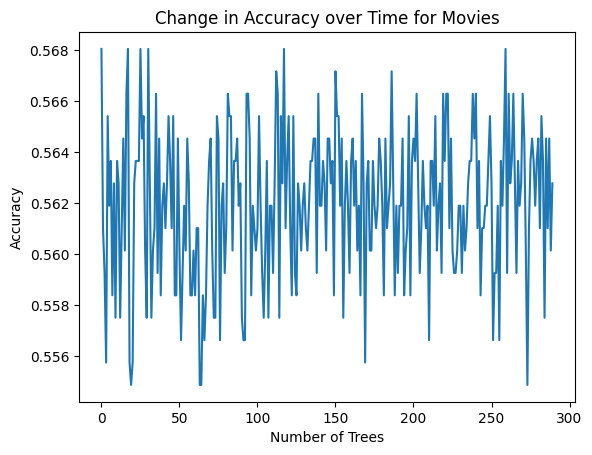

In [42]:
m_forest_scores = []
for i in range(10, 300):
  temp_forest = RandomForestClassifier(n_estimators=i)
  temp_forest.fit(m_X_train, m_Y_train)
  m_forest_scores.append(temp_forest.score(m_X_test, m_Y_test))
plt.plot(m_forest_scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Change in Accuracy over Time for Movies")
plt.show()

This graph is telling me how my accuracy changes as I add more and more trees to my forest. I chose 300 trees Looking at this graph, I can see that it stays pretty much the same throughout. The variation staying between 55 and 57 accuracy. The information I gather from looking at the graph is that the highest accuracy rating is around first few trees. 

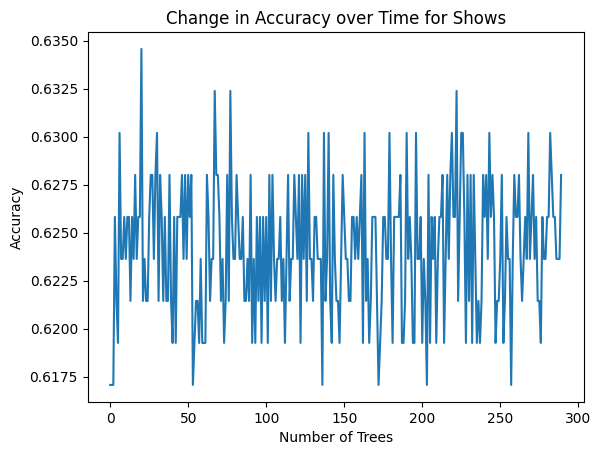

In [43]:
s_forest_scores = []
for i in range(10, 300):
  temp_forest = RandomForestClassifier(n_estimators=i)
  temp_forest.fit(s_X_train, s_Y_train)
  s_forest_scores.append(temp_forest.score(s_X_test, s_Y_test))
plt.plot(s_forest_scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Change in Accuracy over Time for Shows")
plt.show()

The same thing happened for the shows graph, but this time it is between 61 and 63 percent accuracy. The graph does seem to show that the first few trees did not get the highest accuracy, but around the 25 tree mark is when it gets the highest, and then just sits between 62 and 63 accuracy.

### Modifying Tree
I am going to try and increase the accuracy by putting a max depth on my trees. Because there is no magic number for a max depth, I am going to be experimenting with numbers between 5 and 20. I will make 3 forests for shows, and 3 for movies.

In [46]:
movies_forest_1 = RandomForestClassifier(max_depth = 8)
movies_forest_1.fit(m_X_train, m_Y_train)
accuracy_1 = movies_forest_1.score(m_X_test, m_Y_test)
print("Max Depth of 8: " + str(accuracy_1))
movies_forest_2 = RandomForestClassifier(max_depth=12)
movies_forest_2.fit(m_X_train, m_Y_train)
accuracy_2 = movies_forest_2.score(m_X_test, m_Y_test)
print("Max Depth of 12: "+ str(accuracy_2))
movies_forest_3 = RandomForestClassifier(max_depth=20)
movies_forest_3.fit(m_X_train, m_Y_train)
accuracy_3 = movies_forest_3.score(m_X_test, m_Y_test)
print("Max Depth of 20: "+ str(accuracy_3))

Max Depth of 8: 0.5478489903424056
Max Depth of 12: 0.5636523266022827
Max Depth of 20: 0.5671641791044776


The original here was around 56%. So the numbers here show a slight increase when we increase the depth. Therefore, I conclude that the depth size of the trees is not a factor in improving model performance.

In [48]:
shows_forest_1 = RandomForestClassifier(max_depth = 8)
shows_forest_1.fit(s_X_train, s_Y_train)
accuracy_1 = shows_forest_1.score(s_X_test, s_Y_test)
print("Max Depth of 8: " + str(accuracy_1))
shows_forest_2 = RandomForestClassifier(max_depth=12)
shows_forest_2.fit(s_X_train, s_Y_train)
accuracy_2 = shows_forest_2.score(s_X_test, s_Y_test)
print("Max Depth of 12: "+ str(accuracy_2))
shows_forest_3 = RandomForestClassifier(max_depth=20)
shows_forest_3.fit(s_X_train, s_Y_train)
accuracy_3 = shows_forest_3.score(s_X_test, s_Y_test)
print("Max Depth of 20: "+ str(accuracy_3))

Max Depth of 8: 0.612691466083151
Max Depth of 12: 0.6301969365426696
Max Depth of 20: 0.6214442013129103


The original here was around 62.5%. So you can see here that a depth of 12 is the most here, but it's only by half a percent. So I also conclude here that max depth is not a factor in increasing accuracy.

### Adding other features
I am going to add features of duration and release year. The graphs are telling me that the features are just weak in general on their own for predicting rating. What will help is more information for the model to go off of for a prediction. This is why I will now add these two features to improve my accuracy.

I will start by converting these from strings to integers. 

In [52]:
add_movies = netflix_movies[["release_year", "duration"]]
add_movies.dtypes

release_year     int64
duration        object
dtype: object

In [54]:
add_shows = netflix_shows[["release_year", "duration"]]
add_shows.dtypes

release_year     int64
duration        object
dtype: object

In [57]:
add_movies = add_movies.fillna("")
add_shows = add_shows.fillna("")
add_movies["duration"] = add_movies["duration"].str.extract(r"(\d+)").astype(float)
add_shows["duration"] = add_shows["duration"].str.extract(r"(\d+)").astype(float)
add_shows

,release_year,duration
1,2021,2.0
4,2021,2.0
8,2021,9.0
15,2021,4.0
17,2020,2.0
...,...,...
8780,2015,1.0
8795,2015,2.0
8796,2016,2.0
8797,2016,3.0


In [59]:
movies_forest_add_col = pd.concat([movies_forest_concat, add_movies], axis=1)
movies_forest_add_col

,title,rating,Action & Adventure,Anime Features,Children & Family Movies,Classic Movies,Comedies,Cult Movies,Documentaries,Dramas,...,LGBTQ Movies,Movies,Music & Musicals,Romantic Movies,Sci-Fi & Fantasy,Sports Movies,Stand-Up Comedy,Thrillers,release_year,duration
0,Dick Johnson Is Dead,PG-13,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2020,90.0
7,Sankofa,R,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1993,125.0
9,The Starling,PG-13,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,2021,104.0
12,Je Suis Karl,R,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,2021,127.0
24,Jeans,PG-13,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1998,166.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,Zinzana,R,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,2015,96.0
8802,Zodiac,R,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,2007,158.0
8804,Zombieland,R,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2009,88.0
8805,Zoom,PG,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2006,88.0


In [60]:
shows_forest_add_col = pd.concat([shows_forest_concat, add_shows], axis=1)
shows_forest_add_col

,title,rating,Anime Series,British TV Shows,Classic & Cult TV,Crime TV Shows,Docuseries,International TV Shows,Kids' TV,Korean TV Shows,...,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,release_year,duration
1,Blood & Water,R,0,0,0,0,0,1,0,0,...,0,1,0,1,0,0,0,0,2021,2.0
4,Kota Factory,R,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,2021,2.0
8,The Great British Baking Show,PG-13,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2021,9.0
15,Dear White People,R,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,2021,4.0
17,Falsa identidad,R,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,2020,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8780,Yo-Kai Watch,G,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2015,1.0
8795,Yu-Gi-Oh! Arc-V,G,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2015,2.0
8796,Yunus Emre,PG,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,2016,2.0
8797,Zak Storm,G,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2016,3.0


In [61]:
movies_X = movies_forest_add_col.drop(columns=["rating", "title"])
movies_Y = movies_forest_add_col["rating"]
shows_X = shows_forest_add_col.drop(columns=["rating", "title"])
shows_Y = shows_forest_add_col["rating"]

In [62]:
m_X_train, m_X_test, m_Y_train, m_Y_test = train_test_split(movies_X, movies_Y, test_size=0.2, random_state=42)
s_X_train, s_X_test, s_Y_train, s_Y_test = train_test_split(shows_X, shows_Y, test_size=0.2, random_state=42)

In [63]:
movies_forest = RandomForestClassifier()
movies_forest.fit(m_X_train, m_Y_train)
accuracy = movies_forest.score(m_X_test, m_Y_test)
print(accuracy)

0.5566286215978928


So this forest has gone down after adding duration and release year. This shows that this input is just all together too weak to go above 55-56% accuracy.

In [64]:
shows_forest = RandomForestClassifier()
shows_forest.fit(s_X_train, s_Y_train)
accuracy = shows_forest.score(s_X_test, s_Y_test)
print(accuracy)

0.5886214442013129


This has gone down from 62.5% to 58.8% accuracy. This again shows an even bigger drop, and the data added is not helping it is just providing noise which is decreasing the accuracy as a whole.

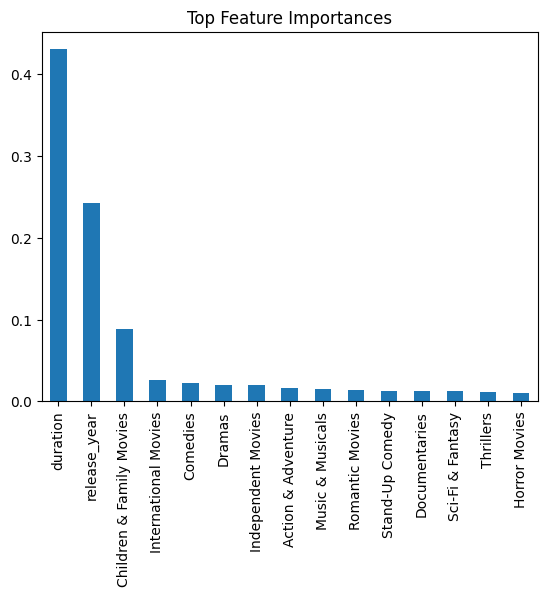

In [67]:
importances = movies_forest.feature_importances_
feat_names = movies_X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

feat_imp.head(15).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()

This graph is very interesting because it is not only matching the logistical regression results, but also the fact that since the multi-hot encoding is spreading out the listed in column, it is having way less of an impact on the results. The duration and release year are taking over the prediciton, and adding those features may not have increased accuracy, but it had a large impact on predicitons. 

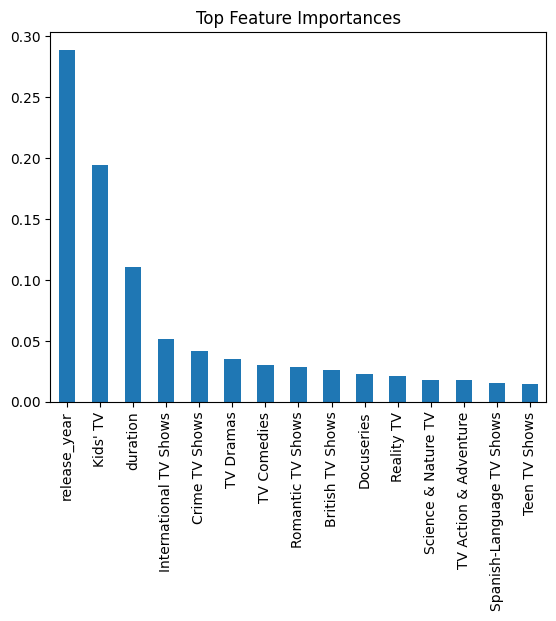

In [68]:
importances = shows_forest.feature_importances_
feat_names = shows_X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

feat_imp.head(15).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()

This graph shows duration having a much less impact on accuracy, matching the general trend of the logistical results graph. The release year seemed to have taken over the results here, along with kid's tv. It seems that adding these two features made a large difference in the results here, more than the small percent changes in accuracy showed previously.